### Interpretability - feature metrics

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
coral_df = pd.read_csv("/work/hs325/World_Corals/Cleaned data CSVs/qc_data.csv")
met_df = pd.read_csv("/work/hs325/World_Corals/Cleaned data CSVs/merged_met_plot_df.csv")
coral_df['scleractinia'] = np.where(coral_df['host_order'] == 'Scleractinia', 1, 0)
met_df['refined_origin'] = met_df['refined_origin'].str.replace('Host', 'Coral')

X = coral_df[coral_df.columns.intersection(met_df['metabolite'])]
y = coral_df['scleractinia']

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88, stratify=y)


/tmp/ipykernel_4007421/989452537.py:1: DtypeWarning: Columns (3,12) have mixed types. Specify dtype option on import or set low_memory=False.
  coral_df = pd.read_csv("/work/hs325/World_Corals/Cleaned data CSVs/qc_data.csv")


### Feature selection

In [3]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import f_classif

## variance threshold doesn't remove enough testing Kbest and percentile

In [4]:
# Initialize a dictionary to store the dataframes
importance_storage = {}

# Define your datasets and models
datasets = {
    "KBest": SelectKBest(f_classif, k=16368),
}

models = {
    "RandomForest": RandomForestClassifier(random_state=88, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=88, use_label_encoder=False, eval_metric='logloss')
}

# Original feature names from the intersection
feature_names = coral_df.columns.intersection(met_df['metabolite']).values

for d_name, selector in datasets.items():
    selector.fit(X_train, y_train)
    X_train_sel = selector.transform(X_train)
    X_test_sel = selector.transform(X_test)
    
    mask = selector.get_support()
    selected_features = feature_names[mask]
    
    for m_name, model in models.items():
        model.fit(X_train_sel, y_train)
        y_pred = model.predict(X_test_sel)
        
        print(f"\n{m_name} on {d_name}")
        print(confusion_matrix(y_test, y_pred))
        
        feat_imp_df = pd.DataFrame({
            'Metabolite': selected_features,
            'Importance': model.feature_importances_
        }).sort_values(by='Importance', ascending=False).reset_index(drop=True)
        
        importance_storage[f"{m_name}_{d_name}"] = feat_imp_df

importance_storage

/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  149   202   268   288   289   370   449   488   546   572   708   793
   847   948   950   966  1019  1098  1112  1122  1127  1247  1334  1437
  1470  1475  1499  1696  1839  1844  1875  1916  2010  2097  2201  2271
  2390  2445  2589  2674  2781  2870  3032  3169  3172  3440  3446  3470
  3641  3720  4253  4263  4297  4326  4382  4416  4529  4569  4788  4823
  4847  4909  5384  5464  5764  5993  6044  6048  6138  6591  6606  6689
  6793  6825  6932  7156  7305  7458  7475  7497  7847  7906  7931  8084
  8123  8182  8193  8677  8991  9113  9274  9452  9472  9640  9713  9768
  9889 10107 10201 10350 10384 10755 10810 11793 12105 12316 12446 12620
 12654 12688 12731 13026 13113 13262 13279 13626 13650 13770 14143 14157
 14374 15230 15271 15352 15448 15594 16337] are constant.
  warnings.warn("Features %s are constant." % constant_f


RandomForest on KBest
[[21  0]
 [ 1 81]]


/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:54:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost on KBest
[[21  0]
 [ 0 82]]


{'RandomForest_KBest':                     Metabolite  Importance
 0       x15256_518_49365_7_407    0.023978
 1        x1831_394_26003_1_922    0.017827
 2      x38490_972_80122_15_591    0.013898
 3      x34473_586_59024_14_249    0.013037
 4      x38232_946_78554_15_489    0.012672
 ...                        ...         ...
 16363  x15343_1353_92371_7_455    0.000000
 16364  x28584_692_42808_12_884    0.000000
 16365    x18000_810_6019_8_543    0.000000
 16366  x34190_951_48365_14_182    0.000000
 16367  x26796_826_65978_12_468    0.000000
 
 [16368 rows x 2 columns],
 'XGBoost_KBest':                     Metabolite  Importance
 0        x1014_394_26002_1_302    0.660484
 1      x39975_976_83346_16_206    0.132430
 2      x27853_600_57246_12_686    0.072871
 3        x1875_530_28797_1_954    0.021955
 4      x40448_910_82144_16_435    0.020798
 ...                        ...         ...
 16363     x400_699_34727_1_124    0.000000
 16364  x39482_719_77858_15_996    0.000000
 16365  

### Perm importance with multicollinear features

In [5]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from collections import defaultdict

In [6]:
feature_names = coral_df.columns.intersection(met_df['metabolite']).values

## Get top 500 metabolites instead from select K best
X_df = pd.DataFrame(
    X,
    columns=coral_df.columns.intersection(met_df['metabolite'])
)

# Split with DataFrames 
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=88, stratify=y
)

# Run SelectKBest on training data
k = min(500, X_train.shape[1])  
selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train, y_train)

top_mets = X_train.columns[selector.get_support()].values


/hpc/group/schultzlab/hs325/miniconda3/envs/gsAI/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  149   202   268   288   289   370   449   488   546   572   708   793
   847   948   950   966  1019  1098  1112  1122  1127  1247  1334  1437
  1470  1475  1499  1696  1839  1844  1875  1916  2010  2097  2201  2271
  2390  2445  2589  2674  2781  2870  3032  3169  3172  3440  3446  3470
  3641  3720  4253  4263  4297  4326  4382  4416  4529  4569  4788  4823
  4847  4909  5384  5464  5764  5993  6044  6048  6138  6591  6606  6689
  6793  6825  6932  7156  7305  7458  7475  7497  7847  7906  7931  8084
  8123  8182  8193  8677  8991  9113  9274  9452  9472  9640  9713  9768
  9889 10107 10201 10350 10384 10755 10810 11793 12105 12316 12446 12620
 12654 12688 12731 13026 13113 13262 13279 13626 13650 13770 14143 14157
 14374 15230 15271 15352 15448 15594 16337] are constant.
  warnings.warn("Features %s are constant." % constant_f

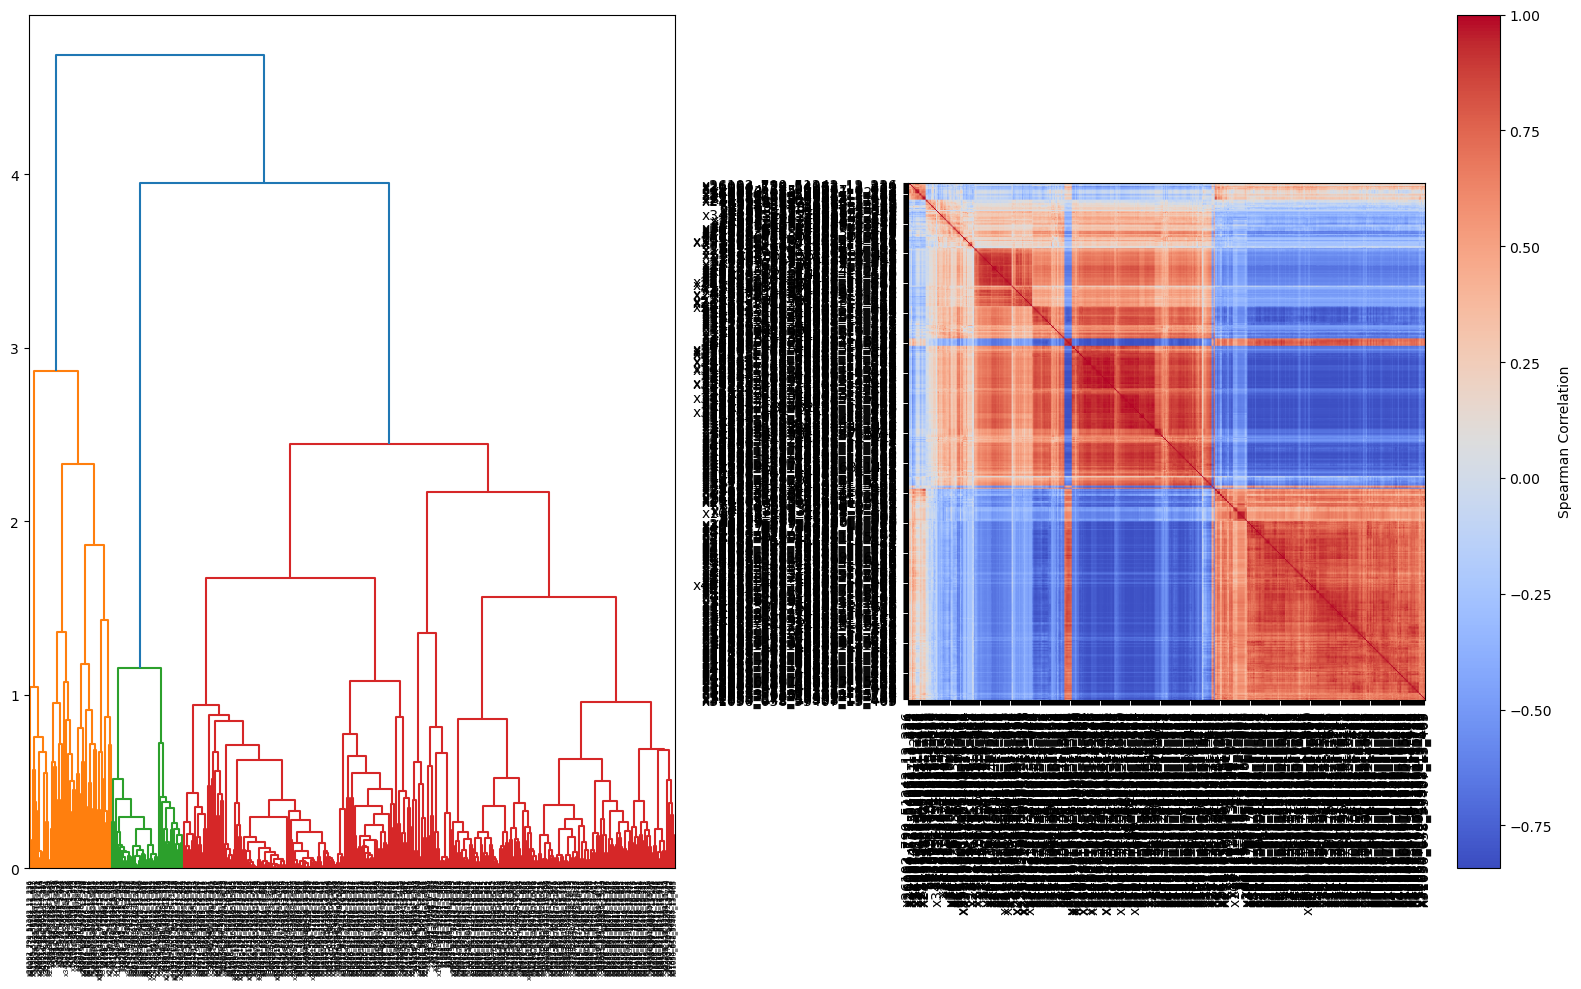

In [7]:
# top_mets = importance_storage["RandomForest_KBest"].head(500)['Metabolite'].values
# top_mets = importance_storage["XGBoost_KBest"].head(500)['Metabolite'].values
top_mets = X_train.columns[selector.get_support()].values

X_df = pd.DataFrame(X, columns=coral_df.columns.intersection(met_df['metabolite']))
X_subset = X_df[top_mets]

corr = spearmanr(X_subset).correlation
corr = (corr + corr.T) / 2
np.fill_diagonal(corr, 1)

distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

dendro = hierarchy.dendrogram(
    dist_linkage, labels=top_mets.tolist(), ax=ax1, leaf_rotation=90
)

im = ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]], cmap='coolwarm')
ax2.set_xticks(np.arange(len(top_mets)))
ax2.set_yticks(np.arange(len(top_mets)))
ax2.set_xticklabels([top_mets[i] for i in dendro["leaves"]], rotation=90)
ax2.set_yticklabels([top_mets[i] for i in dendro["leaves"]])

fig.colorbar(im, ax=ax2, label='Spearman Correlation')
fig.tight_layout()
plt.show()

In [9]:
from collections import defaultdict
from scipy.cluster import hierarchy
from sklearn.ensemble import RandomForestClassifier
import numpy as np

cluster_ids = hierarchy.fcluster(dist_linkage, 1, criterion="distance")
n_features = len(cluster_ids)
print("Number of features in clustering:", n_features)

cluster_id_to_feature_ids = defaultdict(list)
for idx, cluster_id in enumerate(cluster_ids):
    cluster_id_to_feature_ids[cluster_id].append(idx)

selected_features_indices = [v[0] for v in cluster_id_to_feature_ids.values()]

# defensive: make indices unique and sorted
selected_features_indices = sorted(set(selected_features_indices))
selected_features_names = feature_names[selected_features_indices]
print(f"Reduced feature set from {len(feature_names)} to {len(selected_features_names)} clusters.")

def select_columns(X, indices):
    if hasattr(X, "iloc"):   # pandas DataFrame
        return X.iloc[:, indices].values
    else:                    # numpy array
        return X[:, indices]

X_train_sel = select_columns(X_train, selected_features_indices)
X_test_sel  = select_columns(X_test,  selected_features_indices)

print("X_train_sel shape:", X_train_sel.shape)
print("X_test_sel  shape:", X_test_sel.shape)

clf_sel = XGBClassifier(random_state=88, n_jobs=-1)
clf_sel.fit(X_train_sel, y_train)

accuracy = clf_sel.score(X_test_sel, y_test)
print(f"Baseline accuracy on test data with redundant features removed: {accuracy:.2f}")

# print selected feature names
print("Selected feature names after clustering:")
for name in selected_features_names:
    print(name)


Number of features in clustering: 500
Reduced feature set from 16368 to 18 clusters.
X_train_sel shape: (412, 18)
X_test_sel  shape: (103, 18)
Baseline accuracy on test data with redundant features removed: 0.94
Selected feature names after clustering:
x19344_800_60417_9_097
x22863_768_59077_10_971
x25770_796_62218_12_134
x3156_482_36064_2_937
x1935_553_33175_1_992
x21844_792_59098_10_385
x14914_354_37285_7_258
x26380_784_62973_12_327
x28396_774_63786_12_834
x38830_794_72361_15_716
x10553_974_58457_5_456
x37491_896_76901_15_186
x9512_675_67612_5_084
x36625_866_72386_14_846
x35830_890_72292_14_626
x9495_948_56945_5_082
x38127_948_79794_15_431
x35042_890_72194_14_4
